# 의사결정트리 실습
- 분류 트리
- 회귀 트리

## 1. 데이터 준비

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# UCI Wine Quality (red wine 기준)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print(df.shape)
print(df['quality'].value_counts().sort_index())
df.describe()

(1599, 12)
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## 2. 분류 트리 실습

              precision    recall  f1-score   support

        high       0.54      0.49      0.51        43
         low       0.00      0.00      0.00        13
      medium       0.88      0.93      0.90       264

    accuracy                           0.83       320
   macro avg       0.47      0.47      0.47       320
weighted avg       0.79      0.83      0.81       320

[[ 21   0  22]
 [  0   0  13]
 [ 18   1 245]]


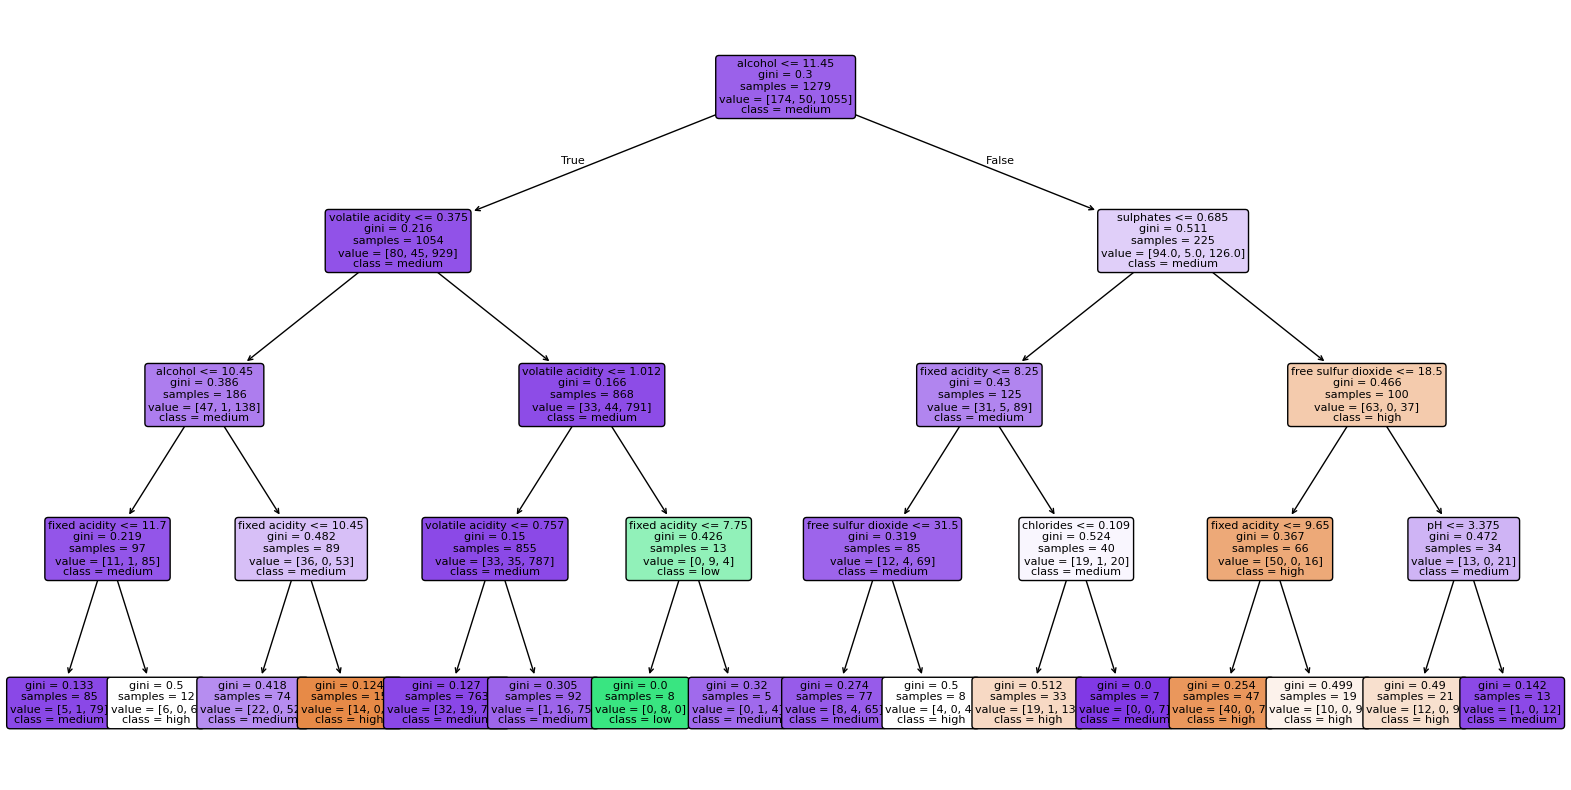

In [ ]:
# 품질 점수를 3단계 등급으로 변환
def to_grade(q):
    if q <= 4: return 'low'
    elif q <= 6: return 'medium'
    else: return 'high'

df['grade'] = df['quality'].apply(to_grade)

X = df.drop(columns=['quality', 'grade'])
y = df['grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_,
          filled=True, rounded=True, fontsize=8)
plt.show()

## 3. 회귀 트리 실습

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns=['quality', 'grade'])
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg = DecisionTreeRegressor(max_depth=4, random_state=42)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 0.4379717420088509
R2: 0.329812065606086


## 4. 하이퍼 파라미터 비교 실습

In [ ]:
depths = [2, 4, 8, None]
results = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)
    results.append((d, train_acc, test_acc))

results_df = pd.DataFrame(results, columns=['max_depth', 'train_acc', 'test_acc'])
print(results_df)

   max_depth  train_acc  test_acc
0        2.0   0.559030  0.531250
1        4.0   0.635653  0.531250
2        8.0   0.807662  0.562500
3        NaN   1.000000  0.559375
